In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install opencv-python matplotlib tqdm

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import shutil

from google.colab import files

In [4]:
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

input_folder = "/content/input_images"
output_folder = "/content/Enhanced_Images_Preprocessed"

shutil.rmtree(input_folder, ignore_errors=True)
shutil.rmtree(output_folder, ignore_errors=True)

os.makedirs(input_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(input_folder)

print("ZIP Extracted Successfully!")

Saving dataset5.zip to dataset5.zip
ZIP Extracted Successfully!


In [5]:
for root, dirs, files in os.walk(input_folder):
    print(root)
    for f in files:
        print("   ",f)

/content/input_images
/content/input_images/dataset5
    im3.jpg
    im4.jpg
    im1.jpg
    im5.jpg
    im2.jpg


In [6]:
def white_balance(img):

    img = img.astype(np.float32)

    b, g, r = cv2.split(img)

    avg_b = np.mean(b)
    avg_g = np.mean(g)
    avg_r = np.mean(r)

    avg_gray = (avg_b + avg_g + avg_r) / 3

    b *= avg_gray/(avg_b+1e-6)
    g *= avg_gray/(avg_g+1e-6)
    r *= avg_gray/(avg_r+1e-6)

    balanced = cv2.merge([b,g,r])

    balanced = np.clip(balanced,0,255)

    return balanced.astype(np.uint8)

In [7]:
def apply_clahe(img):

    lab = cv2.cvtColor(img,cv2.COLOR_BGR2LAB)

    l,a,b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l = clahe.apply(l)

    enhanced = cv2.merge((l,a,b))

    enhanced = cv2.cvtColor(
        enhanced,
        cv2.COLOR_LAB2BGR
    )

    return enhanced

In [8]:
extensions = (".jpg",".jpeg",".png",".bmp")

for root, dirs, files in os.walk(input_folder):

    relative = os.path.relpath(root,input_folder)

    save_dir = os.path.join(output_folder,relative)

    os.makedirs(save_dir,exist_ok=True)

    for file in files:

        if not file.lower().endswith(extensions):
            continue

        path = os.path.join(root,file)

        img = cv2.imread(path)

        if img is None:
            continue

        wb = white_balance(img)

        enhanced = apply_clahe(wb)

        cv2.imwrite(
            os.path.join(save_dir,file),
            enhanced
        )

print("Processing Complete!")

Processing Complete!


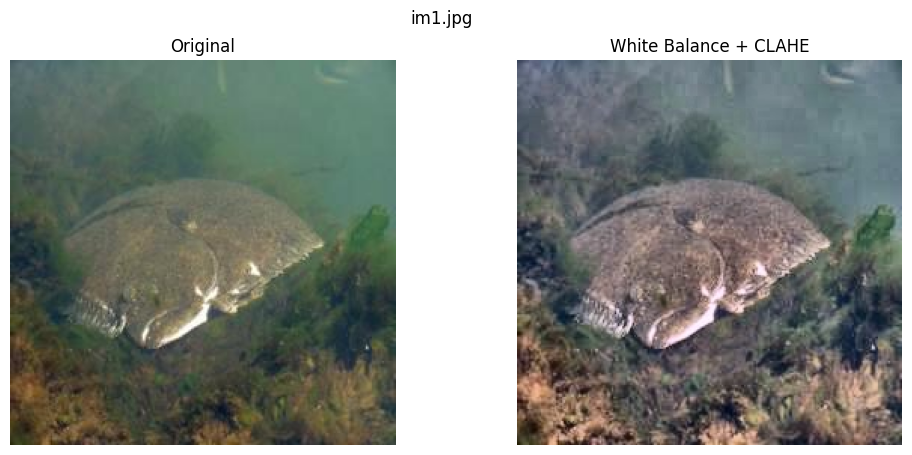

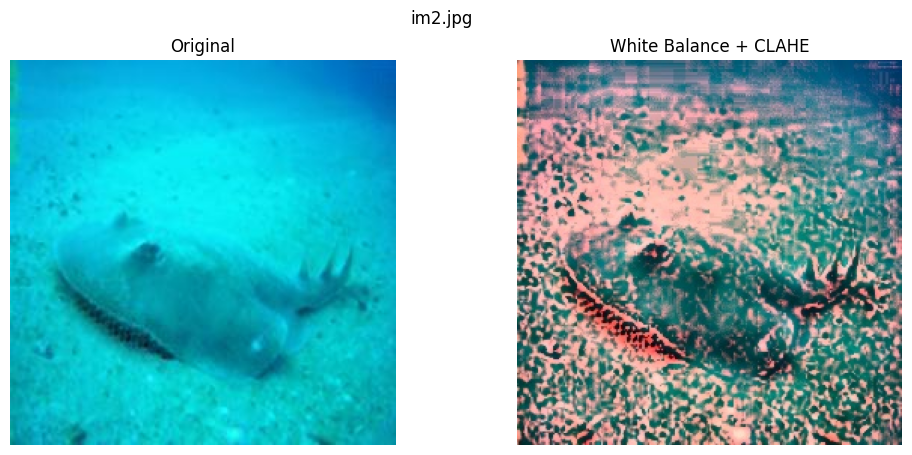

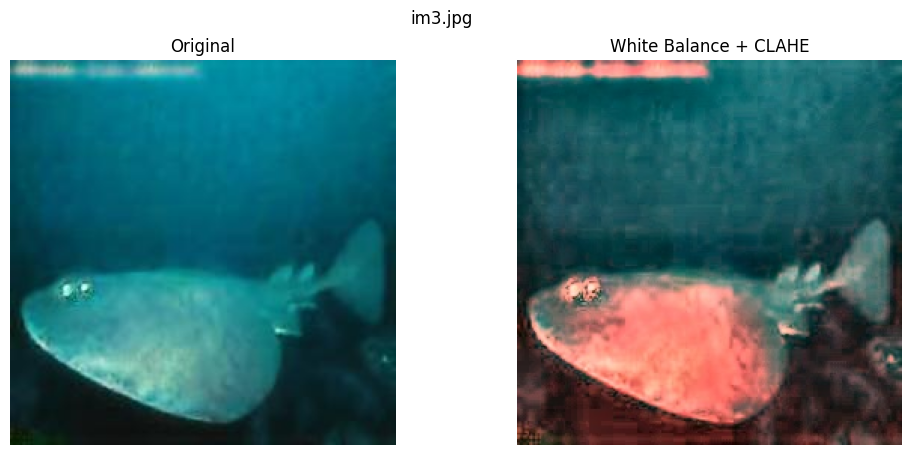

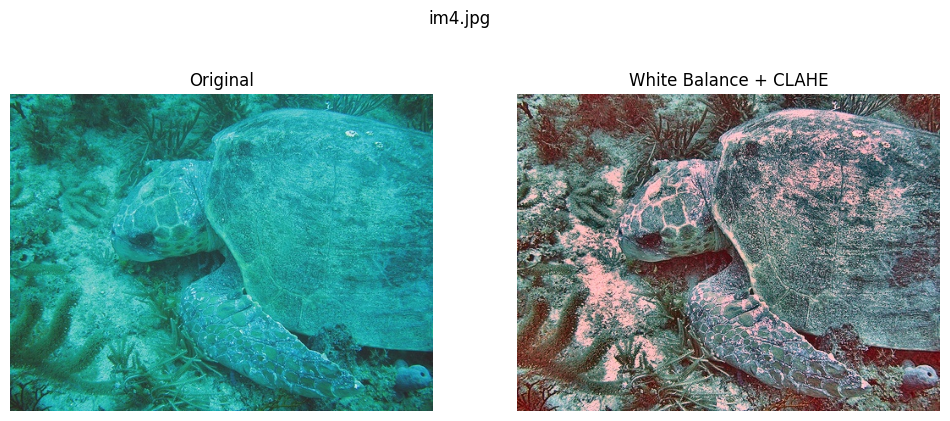

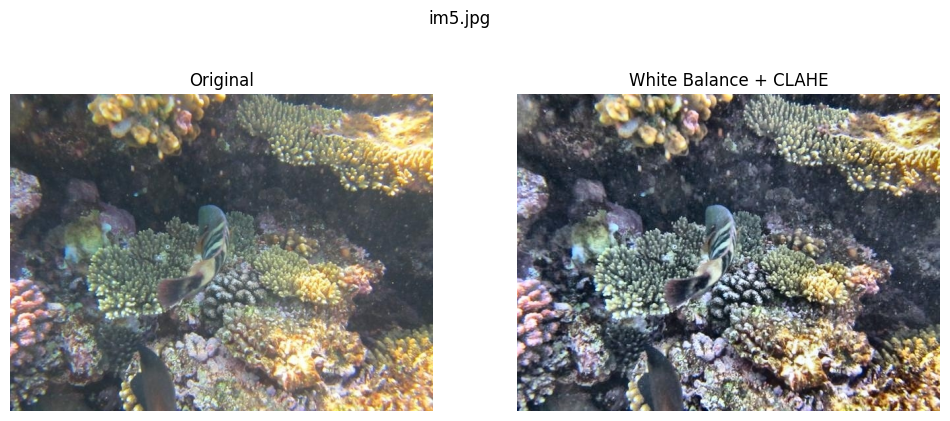

In [9]:
extensions = (".jpg",".jpeg",".png",".bmp")

for root, dirs, files in os.walk(input_folder):

    relative = os.path.relpath(root,input_folder)

    enhanced_root = os.path.join(output_folder,relative)

    for file in sorted(files):

        if not file.lower().endswith(extensions):
            continue

        original_path = os.path.join(root,file)

        enhanced_path = os.path.join(enhanced_root,file)

        if not os.path.exists(enhanced_path):
            continue

        original = cv2.cvtColor(
            cv2.imread(original_path),
            cv2.COLOR_BGR2RGB
        )

        enhanced = cv2.cvtColor(
            cv2.imread(enhanced_path),
            cv2.COLOR_BGR2RGB
        )

        plt.figure(figsize=(12,5))

        plt.subplot(1,2,1)
        plt.imshow(original)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(enhanced)
        plt.title("White Balance + CLAHE")
        plt.axis("off")

        plt.suptitle(file)

        plt.show()

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

drive_output = "/content/drive/MyDrive/WB_CLAHE_Output"

os.makedirs(drive_output, exist_ok=True)

# Copy entire folder while preserving subfolders
for root, dirs, files in os.walk(output_folder):

    relative = os.path.relpath(root, output_folder)

    save_dir = os.path.join(drive_output, relative)

    os.makedirs(save_dir, exist_ok=True)

    for file in files:

        src = os.path.join(root, file)
        dst = os.path.join(save_dir, file)

        shutil.copy2(src, dst)

print("✅ Images saved to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Images saved to Google Drive.


In [11]:
!pip install scipy pandas openpyxl

In [12]:
import cv2
import numpy as np
import pandas as pd
import os
from scipy import ndimage

In [13]:
def uciqe(img):

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)

    L = lab[:,:,0] / 255.0
    a = lab[:,:,1]
    b = lab[:,:,2]

    chroma = np.sqrt(a*a + b*b)

    sigma_c = np.std(chroma)

    con_l = np.percentile(L,99) - np.percentile(L,1)

    sat = chroma / np.sqrt(chroma**2 + L**2 + 1e-6)

    mu_s = np.mean(sat)

    return (
        0.4680*sigma_c +
        0.2745*con_l +
        0.2576*mu_s
    )

In [14]:
def eme(channel, blocksize=8):

    h,w = channel.shape

    eme_score = 0

    k1 = h // blocksize
    k2 = w // blocksize

    for i in range(k1):
        for j in range(k2):

            block = channel[
                i*blocksize:(i+1)*blocksize,
                j*blocksize:(j+1)*blocksize
            ]

            max_val = np.max(block)
            min_val = np.min(block)

            if min_val > 0:
                eme_score += np.log(max_val/min_val)

    return (2/(k1*k2))*eme_score


def uiqm(img):

    img = img.astype(np.float32)

    B,G,R = cv2.split(img)

    rg = R-G
    yb = (R+G)/2-B

    uicm = np.std(rg) + np.std(yb)

    gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY)

    uism = eme(gray)

    uiconm = np.std(gray)

    return (
        0.0282*uicm +
        0.2953*uism +
        3.5753*uiconm
    )

In [15]:
results = []

extensions = (".jpg", ".jpeg", ".png", ".bmp")

for root, dirs, files in os.walk(output_folder):

    relative = os.path.relpath(root, output_folder)

    for file in sorted(files):

        if not file.lower().endswith(extensions):
            continue

        path = os.path.join(root, file)

        img = cv2.imread(path)

        if img is None:
            continue

        uiqm_score = uiqm(img)
        uciqe_score = uciqe(img)

        results.append({
            "Folder": relative,
            "Image": file,
            "UIQM": uiqm_score,
            "UCIQE": uciqe_score
        })

df = pd.DataFrame(results)

df.head()

,Folder,Image,UIQM,UCIQE
0,dataset5,im1.jpg,117.042993,4.192506
1,dataset5,im2.jpg,182.837912,8.349293
2,dataset5,im3.jpg,165.781106,11.536588
3,dataset5,im4.jpg,179.371902,5.401222
4,dataset5,im5.jpg,213.212238,5.024218


In [16]:
csv_path = "/content/drive/MyDrive/WB_CLAHE_Output/UIQM_UCIQE_Results.csv"
excel_path = "/content/drive/MyDrive/WB_CLAHE_Output/UIQM_UCIQE_Results.xlsx"

df.to_csv(csv_path, index=False)
df.to_excel(excel_path, index=False)

print("✅ CSV saved:", csv_path)
print("✅ Excel saved:", excel_path)

✅ CSV saved: /content/drive/MyDrive/WB_CLAHE_Output/UIQM_UCIQE_Results.csv
✅ Excel saved: /content/drive/MyDrive/WB_CLAHE_Output/UIQM_UCIQE_Results.xlsx
